In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.4f}".format)

FIXED_LAM = 1.9675
TENOR_YEARS = {
    "1mo": 1/12, "3mo": 3/12, "6mo": 6/12,
    "1yr": 1, "2yr": 2, "3yr": 3, "5yr": 5,
    "7yr": 7, "10yr": 10, "20yr": 20, "30yr": 30,
}
TENORS = list(TENOR_YEARS.keys())
TAUS   = list(TENOR_YEARS.values())

def ns_yield(tau, beta0, beta1, beta2, lam=FIXED_LAM):
    tau = np.maximum(tau, 1e-6)
    factor = (1 - np.exp(-tau / lam)) / (tau / lam)
    return beta0 + beta1 * factor + beta2 * (factor - np.exp(-tau / lam))

In [2]:
portfolio   = pd.read_csv("data/portfolio.csv",      index_col="label")
krd         = pd.read_csv("data/krd.csv",            index_col="bond")
pnl_df      = pd.read_csv("data/scenario_pnl.csv",  index_col="scenario")
moves       = pd.read_csv("data/scenario_moves.csv", index_col="scenario")
scenarios   = pd.read_csv("data/scenarios.csv",      index_col="scenario")
base_curve  = pd.read_csv("data/base_curve.csv",     index_col=0).iloc[:, 0]

# Portfolio-level risk metrics
port_price    = portfolio["price"].sum()
port_dv01     = portfolio["dv01"].sum()
port_dur      = (portfolio["mod_dur"] * portfolio["price"]).sum() / port_price
port_krd      = (krd.T * portfolio["price"]).sum(axis=1) / port_price

print(f"Portfolio value : ${port_price/1e6:.2f}M")
print(f"Portfolio DV01  : ${port_dv01:,.0f}")
print(f"Portfolio duration: {port_dur:.2f} years")
print(f"\nPortfolio KRD profile:")
for t, k in port_krd.items():
    print(f"  {t:>5s}: {k:.3f} years")

Portfolio value : $51.55M
Portfolio DV01  : $45,581
Portfolio duration: 8.84 years

Portfolio KRD profile:
    1yr: 0.033 years
    2yr: 0.248 years
    3yr: 0.160 years
    5yr: 0.975 years
    7yr: 1.155 years
   10yr: 2.463 years
   20yr: 1.866 years
   30yr: 1.913 years


In [3]:
# Standard market DV01 per contract (approximate)
futures = pd.DataFrame({
    "name":     ["2yr Note",  "5yr Note",  "10yr Note", "30yr Bond"],
    "ticker":   ["TU",        "FV",        "TY",        "US"],
    "dv01_per": [40.0,        85.0,        160.0,       310.0],
    # KRD approximation: futures price is most sensitive to their
    # delivery basket maturity — modeled as concentrated at one tenor
    "krd_tenor":["2yr",       "5yr",       "10yr",      "30yr"],
}, index=["TU", "FV", "TY", "US"])

# Transaction cost: 0.5bp per contract per side
TC_PER_CONTRACT = 0.5 * futures["dv01_per"]  # $ cost per contract

print("Treasury Futures Specifications:")
print(futures[["name","dv01_per","krd_tenor"]].to_string())
print(f"\nTransaction costs per contract:")
for tkr in futures.index:
    print(f"  {tkr}: ${TC_PER_CONTRACT[tkr]:.2f}")

Treasury Futures Specifications:
         name  dv01_per krd_tenor
TU   2yr Note   40.0000       2yr
FV   5yr Note   85.0000       5yr
TY  10yr Note  160.0000      10yr
US  30yr Bond  310.0000      30yr

Transaction costs per contract:
  TU: $20.00
  FV: $42.50
  TY: $80.00
  US: $155.00


In [4]:
# Single instrument: 10yr futures (TY)
# Contracts = portfolio DV01 / DV01 per TY contract

ty_dv01    = futures.loc["TY", "dv01_per"]
n_ty       = port_dv01 / ty_dv01
n_ty_round = round(n_ty)

# Residual DV01 after hedge
residual_dv01_s1 = port_dv01 - n_ty_round * ty_dv01

# Transaction cost
tc_s1 = n_ty_round * TC_PER_CONTRACT["TY"]

print("STRATEGY 1 — Duration Neutral (TY futures only)")
print("=" * 50)
print(f"  Portfolio DV01     : ${port_dv01:,.0f}")
print(f"  TY DV01/contract   : ${ty_dv01:,.0f}")
print(f"  Contracts needed   : {n_ty:.2f}")
print(f"  Contracts (rounded): {n_ty_round}")
print(f"  Residual DV01      : ${residual_dv01_s1:,.0f}")
print(f"  Hedge ratio        : {n_ty_round * ty_dv01 / port_dv01 * 100:.1f}%")
print(f"  Transaction cost   : ${tc_s1:,.0f}")

STRATEGY 1 — Duration Neutral (TY futures only)
  Portfolio DV01     : $45,581
  TY DV01/contract   : $160
  Contracts needed   : 284.88
  Contracts (rounded): 285
  Residual DV01      : $-19
  Hedge ratio        : 100.0%
  Transaction cost   : $22,800


In [5]:
# ── CELL 5: Strategy 2 — Key Rate Duration Hedge ─────────────
# Multi-instrument hedge using TU, FV, TY, US
# Match portfolio KRD at each tenor bucket
# System: portfolio_krd[t] = sum_i(n_i × futures_krd[i][t])

# KRD tenors we have data for
krd_tenors = ["2yr", "5yr", "10yr", "30yr"]

# Portfolio KRD at these four tenors (in dollar terms = KRD × portfolio value)
port_krd_dollar = {t: port_krd[t] * port_price for t in krd_tenors}

# Futures KRD matrix: each futures contract's KRD at each tenor
# Approximation: TU has all its KRD at 2yr, FV at 5yr, etc.
# Dollar KRD per contract = DV01 per contract / 0.0001
# (DV01 = KRD × Price × 0.0001, so KRD × Price = DV01 / 0.0001)
futures_krd_matrix = np.zeros((4, 4))  # [futures, tenors]
for i, tkr in enumerate(["TU", "FV", "TY", "US"]):
    krd_t = futures.loc[tkr, "krd_tenor"]
    j     = krd_tenors.index(krd_t)
    # Dollar KRD per contract at its tenor
    futures_krd_matrix[i, j] = futures.loc[tkr, "dv01_per"] / 0.0001

# Target: zero out portfolio KRD at each tenor
target_krd = np.array([port_krd_dollar[t] for t in krd_tenors])

# Solve: futures_krd_matrix.T @ n = target_krd
# Least squares solution (system is exactly determined: 4 futures, 4 tenors)
A = futures_krd_matrix.T
b = target_krd

n_krd, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
n_krd_round    = np.round(n_krd).astype(int)

# Transaction costs
tc_s2 = sum(abs(n_krd_round[i]) * TC_PER_CONTRACT[tkr]
            for i, tkr in enumerate(["TU", "FV", "TY", "US"]))

print("STRATEGY 2 — Key Rate Duration Hedge")
print("=" * 50)
for i, tkr in enumerate(["TU", "FV", "TY", "US"]):
    print(f"  {tkr} ({futures.loc[tkr,'name']:12s}): "
          f"{n_krd_round[i]:>6d} contracts  "
          f"(exact: {n_krd[i]:.1f})")
print(f"\n  Total transaction cost: ${tc_s2:,.0f}")
print(f"  vs Strategy 1 cost   : ${tc_s1:,.0f}")

STRATEGY 2 — Key Rate Duration Hedge
  TU (2yr Note    ):     32 contracts  (exact: 32.0)
  FV (5yr Note    ):     59 contracts  (exact: 59.1)
  TY (10yr Note   ):     79 contracts  (exact: 79.4)
  US (30yr Bond   ):     32 contracts  (exact: 31.8)

  Total transaction cost: $14,428
  vs Strategy 1 cost   : $22,800


In [18]:
# ── CELL 5b: Strategy 4 — Combined Hedge (KRD mix + full DV01) ──
# S2 contract mix gives the right curve shape hedge
# but undershoots total DV01 coverage
# Scale all S2 contracts proportionally to match portfolio DV01

# Current DV01 coverage from S2
s2_dv01_covered = sum(
    n_krd_round[i] * futures.loc[tkr, "dv01_per"]
    for i, tkr in enumerate(["TU", "FV", "TY", "US"])
)

scale_factor = port_dv01 / s2_dv01_covered
n_s4 = {tkr: round(n_krd_round[i] * scale_factor)
        for i, tkr in enumerate(["TU", "FV", "TY", "US"])}

# Transaction cost
tc_s4 = sum(abs(n_s4[tkr]) * TC_PER_CONTRACT[tkr]
            for tkr in ["TU", "FV", "TY", "US"])

print("STRATEGY 4 — Combined Hedge (KRD mix, full DV01)")
print("=" * 50)
print(f"  S2 DV01 covered  : ${s2_dv01_covered:,.0f}")
print(f"  Portfolio DV01   : ${port_dv01:,.0f}")
print(f"  Scale factor     : {scale_factor:.3f}")
print()
for tkr in ["TU", "FV", "TY", "US"]:
    print(f"  {tkr} ({futures.loc[tkr,'name']:12s}): "
          f"SHORT {n_s4[tkr]:>4d} contracts")
print(f"\n  Transaction cost : ${tc_s4:,.0f}")
print(f"  vs S1 cost       : ${tc_s1:,.0f}")
print(f"  vs S2 cost       : ${tc_s2:,.0f}")

STRATEGY 4 — Combined Hedge (KRD mix, full DV01)
  S2 DV01 covered  : $28,855
  Portfolio DV01   : $45,581
  Scale factor     : 1.580

  TU (2yr Note    ): SHORT   51 contracts
  FV (5yr Note    ): SHORT   93 contracts
  TY (10yr Note   ): SHORT  125 contracts
  US (30yr Bond   ): SHORT   51 contracts

  Transaction cost : $22,878
  vs S1 cost       : $22,800
  vs S2 cost       : $14,428


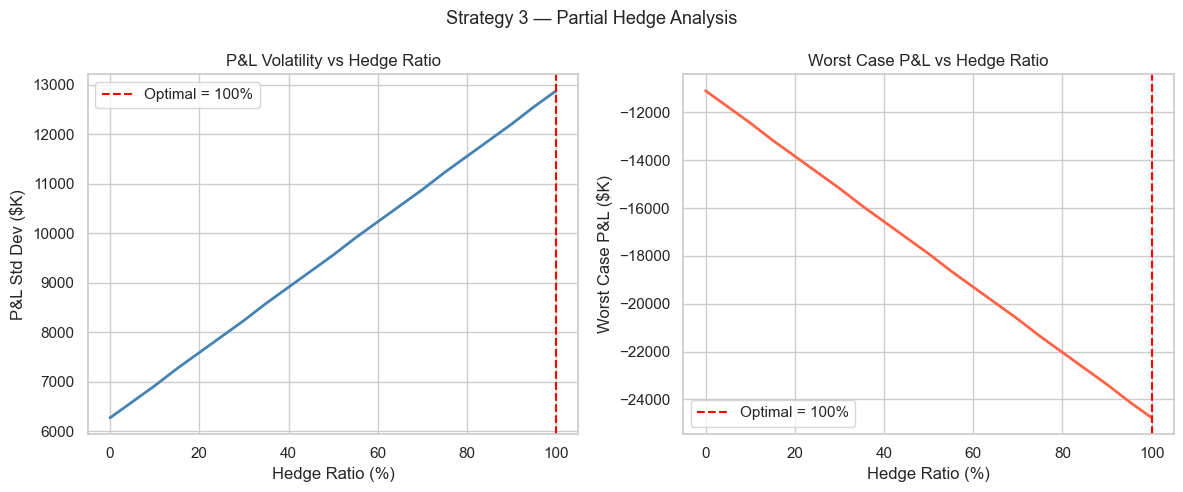

Optimal hedge ratio  : 100%
Min P&L volatility   : $12,877.6K


In [12]:
#── CELL 6: Strategy 3 — Partial Hedge ───────────────────────
# Vary hedge ratio from 0% to 100% using TY futures
# Find optimal ratio that minimizes P&L volatility across scenarios

non_mc_scenarios = [s for s in pnl_df.index if not s.startswith("mc_")]
unhedged_pnl     = pnl_df.loc[non_mc_scenarios, "total"].values

hedge_ratios  = np.arange(0, 1.01, 0.05)
pnl_vol       = []
pnl_worst     = []

for hr in hedge_ratios:
    n_contracts = round(n_ty * hr)
    futures_pnl = []
    for sc in non_mc_scenarios:
        # Use 10yr move specifically — TY futures track 10yr rate
        move_10yr = moves.loc[sc, "10yr"]
        fut_pnl   = -n_contracts * ty_dv01 * move_10yr
        futures_pnl.append(fut_pnl)

    hedged = unhedged_pnl + np.array(futures_pnl)
    pnl_vol.append(np.std(hedged))
    pnl_worst.append(np.min(hedged))

# Optimal = minimize worst case loss (more meaningful than variance)
optimal_idx   = np.argmin(pnl_worst)
optimal_ratio = hedge_ratios[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(hedge_ratios * 100, np.array(pnl_vol) / 1e3,
             "steelblue", linewidth=2)
axes[0].axvline(optimal_ratio * 100, color="red", linestyle="--",
                label=f"Optimal = {optimal_ratio*100:.0f}%")
axes[0].set_xlabel("Hedge Ratio (%)")
axes[0].set_ylabel("P&L Std Dev ($K)")
axes[0].set_title("P&L Volatility vs Hedge Ratio")
axes[0].legend()

axes[1].plot(hedge_ratios * 100, np.array(pnl_worst) / 1e3,
             "tomato", linewidth=2)
axes[1].axvline(optimal_ratio * 100, color="red", linestyle="--",
                label=f"Optimal = {optimal_ratio*100:.0f}%")
axes[1].set_xlabel("Hedge Ratio (%)")
axes[1].set_ylabel("Worst Case P&L ($K)")
axes[1].set_title("Worst Case P&L vs Hedge Ratio")
axes[1].legend()

plt.suptitle("Strategy 3 — Partial Hedge Analysis", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_partial_hedge.png", dpi=150)
plt.show()

print(f"Optimal hedge ratio  : {optimal_ratio*100:.0f}%")
print(f"Min P&L volatility   : ${pnl_vol[optimal_idx]/1e3:,.1f}K")


In [31]:
# ── CELL 7: Compute Hedged P&L for All Strategies ────────────
# ── CELL 13: Update futures_pnl_strategy for new scenarios ───
def futures_pnl_strategy(contracts_dict, scenario_name=None,
                          override_moves=None):
    total    = 0
    sc_moves = (pd.Series(override_moves, index=TENORS)
                if override_moves is not None
                else moves.loc[scenario_name])
    for tkr, n in contracts_dict.items():
        krd_t    = futures.loc[tkr, "krd_tenor"]
        move_bps = sc_moves.get(krd_t, sc_moves.mean())
        dv01_c   = futures.loc[tkr, "dv01_per"]
        total   += -n * dv01_c * move_bps
    return total

print("futures_pnl_strategy updated — supports override_moves")

s1_contracts = {"TY": -n_ty_round}
s2_contracts = {tkr: -n_krd_round[i]
                for i, tkr in enumerate(["TU", "FV", "TY", "US"])}
n_partial    = round(n_ty * optimal_ratio)
s3_contracts = {"TY": -n_partial}
s4_contracts = {"TU": -n_s4["TU"], "FV": -n_s4["FV"],
                "TY": -n_s4["TY"], "US": -n_s4["US"]}

hedged_records = []
for sc in non_mc_scenarios:
    unhedged = pnl_df.loc[sc, "total"]
    fpnl_s1  = futures_pnl_strategy(s1_contracts, sc)
    fpnl_s2  = futures_pnl_strategy(s2_contracts, sc)
    fpnl_s3  = futures_pnl_strategy(s3_contracts, sc)
    fpnl_s4  = futures_pnl_strategy(s4_contracts, sc)

    hedged_records.append({
        "scenario":   sc,
        "unhedged":   unhedged,
        "s1_futures": fpnl_s1,
        "s2_futures": fpnl_s2,
        "s3_futures": fpnl_s3,
        "s4_futures": fpnl_s4,
        "s1_hedged":  unhedged + fpnl_s1,
        "s2_hedged":  unhedged + fpnl_s2,
        "s3_hedged":  unhedged + fpnl_s3,
        "s4_hedged":  unhedged + fpnl_s4,
    })

hedged_df = pd.DataFrame(hedged_records).set_index("scenario")
hedged_df.to_csv("data/hedged_pnl.csv")
print("Hedged P&L computed for all strategies")
print(hedged_df[["unhedged","s1_hedged","s2_hedged",
                 "s3_hedged","s4_hedged"]].div(1e3).round(1).to_string())

futures_pnl_strategy updated — supports override_moves
Hedged P&L computed for all strategies
                      unhedged  s1_hedged  s2_hedged  s3_hedged  s4_hedged
scenario                                                                  
parallel_up_100     -4232.6000   327.4000 -1347.1000   327.4000   342.9000
parallel_up_200     -7896.1000  1223.9000 -2125.1000  1223.9000  1254.9000
parallel_up_300    -11092.9000  2587.1000 -2436.4000  2587.1000  2633.6000
parallel_down_100    4932.7000   372.7000  2047.2000   372.7000   357.2000
parallel_down_200   10734.1000  1614.1000  4963.1000  1614.1000  1583.1000
bear_steepener      -5584.8000  1255.2000 -1384.6000  1255.2000  1074.4000
bull_steepener       7320.2000   480.2000  3120.0000   480.2000   661.0000
bear_flattener      -2191.9000    88.1000  -621.2000    88.1000   299.8000
bull_flattener       2351.7000    71.7000   780.9000    71.7000  -140.1000
inversion            -224.0000  -224.0000    32.0000  -224.0000   184.0000
hump  

In [21]:
# ── CELL 8: Hedge Effectiveness Analysis ─────────────────────
eff_records = []
for sc in non_mc_scenarios:
    row = hedged_df.loc[sc]
    unh = row["unhedged"]

    def effectiveness(hedged_pnl, unhedged_pnl):
        if abs(unhedged_pnl) < 1:
            return np.nan
        return (1 - abs(hedged_pnl) / abs(unhedged_pnl)) * 100

    eff_records.append({
        "scenario":     sc,
        "unhedged_$K":  unh / 1e3,
        "s1_hedged_$K": row["s1_hedged"] / 1e3,
        "s2_hedged_$K": row["s2_hedged"] / 1e3,
        "s4_hedged_$K": row["s4_hedged"] / 1e3,
        "s1_eff_%":     effectiveness(row["s1_hedged"], unh),
        "s2_eff_%":     effectiveness(row["s2_hedged"], unh),
        "s4_eff_%":     effectiveness(row["s4_hedged"], unh),
        "s2_vs_s1_%":   effectiveness(row["s1_hedged"], unh) -
                        effectiveness(row["s2_hedged"], unh),
        "s4_vs_s1_%":   effectiveness(row["s1_hedged"], unh) -
                        effectiveness(row["s4_hedged"], unh),
    })

eff_df = pd.DataFrame(eff_records).set_index("scenario")
eff_df.to_csv("data/hedge_effectiveness.csv")

print("\nHEDGE EFFECTIVENESS SUMMARY")
print("=" * 95)
print(f"{'Scenario':<25} {'Unhedged':>10} {'S1 Hedged':>10} "
      f"{'S2 Hedged':>10} {'S4 Hedged':>10} "
      f"{'S1 Eff%':>8} {'S2 Eff%':>8} {'S4 Eff%':>8}")
print("-" * 95)
for sc, row in eff_df.iterrows():
    print(f"{sc:<25} {row['unhedged_$K']:>10,.0f} {row['s1_hedged_$K']:>10,.0f} "
          f"{row['s2_hedged_$K']:>10,.0f} {row['s4_hedged_$K']:>10,.0f} "
          f"{row['s1_eff_%']:>7.1f}% {row['s2_eff_%']:>7.1f}% "
          f"{row['s4_eff_%']:>7.1f}%")


HEDGE EFFECTIVENESS SUMMARY
Scenario                    Unhedged  S1 Hedged  S2 Hedged  S4 Hedged  S1 Eff%  S2 Eff%  S4 Eff%
-----------------------------------------------------------------------------------------------
parallel_up_100               -4,233        327     -1,347        343    92.3%    68.2%    91.9%
parallel_up_200               -7,896      1,224     -2,125      1,255    84.5%    73.1%    84.1%
parallel_up_300              -11,093      2,587     -2,436      2,634    76.7%    78.0%    76.3%
parallel_down_100              4,933        373      2,047        357    92.4%    58.5%    92.8%
parallel_down_200             10,734      1,614      4,963      1,583    85.0%    53.8%    85.3%
bear_steepener                -5,585      1,255     -1,385      1,074    77.5%    75.2%    80.8%
bull_steepener                 7,320        480      3,120        661    93.4%    57.4%    91.0%
bear_flattener                -2,192         88       -621        300    96.0%    71.7%    86.3%
bu

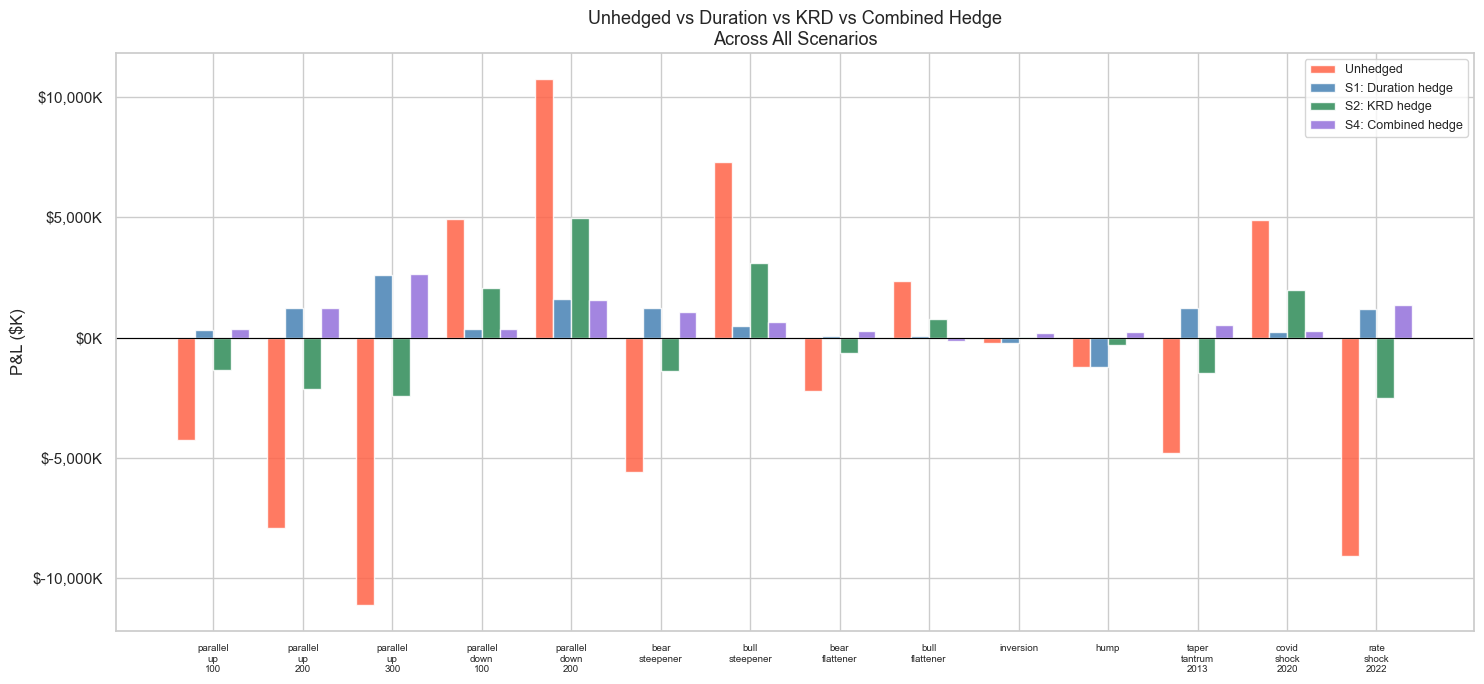

In [22]:
# ── CELL 9: Hero Chart — Unhedged vs S1 vs S2 vs S4 ─────────
fig, ax = plt.subplots(figsize=(15, 7))

x     = np.arange(len(non_mc_scenarios))
width = 0.20

b1 = ax.bar(x - width*1.5, hedged_df["unhedged"]  / 1e3, width,
            label="Unhedged",          color="tomato",       alpha=0.85, edgecolor="white")
b2 = ax.bar(x - width*0.5, hedged_df["s1_hedged"] / 1e3, width,
            label="S1: Duration hedge", color="steelblue",   alpha=0.85, edgecolor="white")
b3 = ax.bar(x + width*0.5, hedged_df["s2_hedged"] / 1e3, width,
            label="S2: KRD hedge",      color="seagreen",    alpha=0.85, edgecolor="white")
b4 = ax.bar(x + width*1.5, hedged_df["s4_hedged"] / 1e3, width,
            label="S4: Combined hedge", color="mediumpurple", alpha=0.85, edgecolor="white")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", "\n") for s in non_mc_scenarios],
                   fontsize=7, rotation=0)
ax.set_ylabel("P&L ($K)")
ax.set_title("Unhedged vs Duration vs KRD vs Combined Hedge\nAcross All Scenarios",
             fontsize=13)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
plt.tight_layout()
plt.savefig("data/fig_hedge_comparison.png", dpi=150)
plt.show()

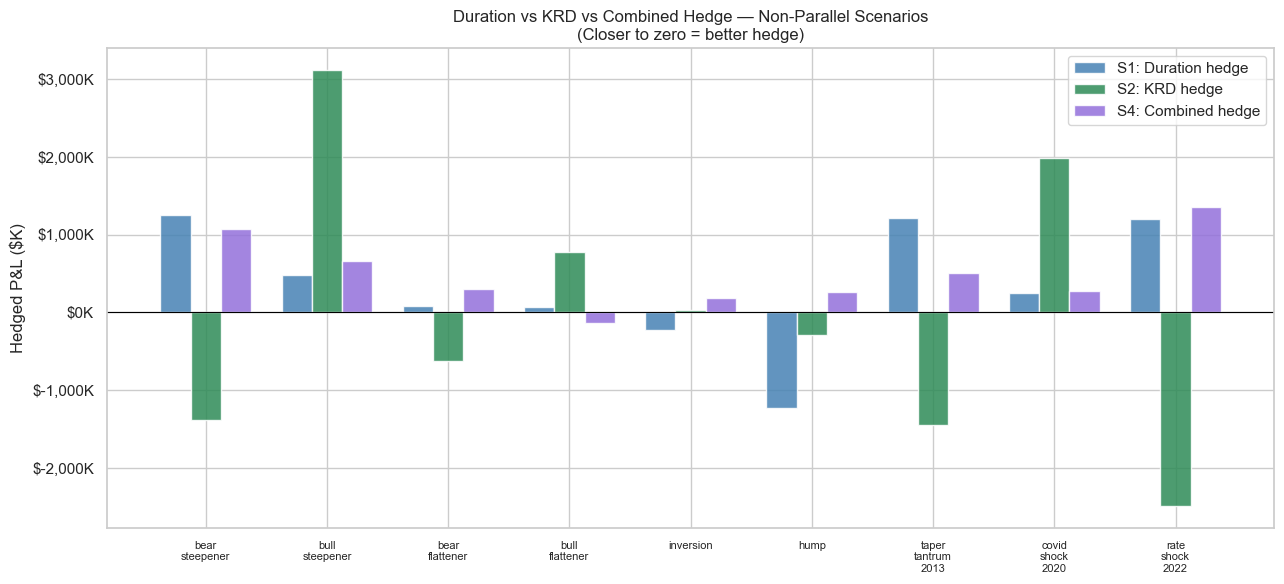

In [23]:
# ── CELL 10: KRD vs Duration vs Combined — Non-Parallel Scenarios ──
non_parallel = ["bear_steepener", "bull_steepener", "bear_flattener",
                "bull_flattener", "inversion", "hump",
                "taper_tantrum_2013", "covid_shock_2020", "rate_shock_2022"]
non_parallel = [s for s in non_parallel if s in hedged_df.index]

fig, ax = plt.subplots(figsize=(13, 6))
x     = np.arange(len(non_parallel))
width = 0.25

ax.bar(x - width,   hedged_df.loc[non_parallel, "s1_hedged"] / 1e3,
       width, label="S1: Duration hedge", color="steelblue",    alpha=0.85, edgecolor="white")
ax.bar(x,           hedged_df.loc[non_parallel, "s2_hedged"] / 1e3,
       width, label="S2: KRD hedge",      color="seagreen",     alpha=0.85, edgecolor="white")
ax.bar(x + width,   hedged_df.loc[non_parallel, "s4_hedged"] / 1e3,
       width, label="S4: Combined hedge", color="mediumpurple",  alpha=0.85, edgecolor="white")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", "\n") for s in non_parallel], fontsize=8)
ax.set_ylabel("Hedged P&L ($K)")
ax.set_title("Duration vs KRD vs Combined Hedge — Non-Parallel Scenarios\n"
             "(Closer to zero = better hedge)", fontsize=12)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
plt.tight_layout()
plt.savefig("data/fig_krd_vs_duration.png", dpi=150)
plt.show()

In [24]:
# ── CELL 11: Hedge Ratios Summary Table ──────────────────────
n_partial = round(n_ty * optimal_ratio)
tc_s3     = n_partial * TC_PER_CONTRACT["TY"]

print("HEDGE RATIOS SUMMARY")
print("=" * 55)

print("\nStrategy 1 — Duration Neutral:")
print(f"  TY (10yr futures): SHORT {n_ty_round} contracts")
print(f"  Notional hedged  : ${n_ty_round * ty_dv01 / port_dv01 * port_price / 1e6:.2f}M")
print(f"  Transaction cost : ${tc_s1:,.0f}")

print("\nStrategy 2 — KRD Hedge:")
for i, tkr in enumerate(["TU", "FV", "TY", "US"]):
    direction = "SHORT" if n_krd_round[i] > 0 else "LONG"
    print(f"  {tkr} ({futures.loc[tkr,'name']:12s}): "
          f"{direction} {abs(n_krd_round[i])} contracts")
print(f"  Transaction cost : ${tc_s2:,.0f}")

print(f"\nStrategy 3 — Partial Hedge ({optimal_ratio*100:.0f}%):")
print(f"  TY (10yr futures): SHORT {n_partial} contracts")
print(f"  Transaction cost : ${tc_s3:,.0f}")

print("\nStrategy 4 — Combined Hedge (KRD mix + full DV01):")
for tkr in ["TU", "FV", "TY", "US"]:
    direction = "SHORT" if n_s4[tkr] > 0 else "LONG"
    print(f"  {tkr} ({futures.loc[tkr,'name']:12s}): "
          f"{direction} {abs(n_s4[tkr])} contracts")
print(f"  Transaction cost : ${tc_s4:,.0f}")

print("\nCost comparison:")
print(f"  S1: ${tc_s1:,.0f}  S2: ${tc_s2:,.0f}  "
      f"S3: ${tc_s3:,.0f}  S4: ${tc_s4:,.0f}")

hedge_ratios_df = pd.DataFrame({
    "S1": [n_ty_round if tkr == "TY" else 0 for tkr in ["TU","FV","TY","US"]],
    "S2": n_krd_round.tolist(),
    "S3": [n_partial  if tkr == "TY" else 0 for tkr in ["TU","FV","TY","US"]],
    "S4": [n_s4[tkr] for tkr in ["TU","FV","TY","US"]],
}, index=["TU","FV","TY","US"])
hedge_ratios_df.to_csv("data/hedge_ratios.csv")
print("\nSaved to data/hedge_ratios.csv")
hedge_ratios_df

HEDGE RATIOS SUMMARY

Strategy 1 — Duration Neutral:
  TY (10yr futures): SHORT 285 contracts
  Notional hedged  : $51.57M
  Transaction cost : $22,800

Strategy 2 — KRD Hedge:
  TU (2yr Note    ): SHORT 32 contracts
  FV (5yr Note    ): SHORT 59 contracts
  TY (10yr Note   ): SHORT 79 contracts
  US (30yr Bond   ): SHORT 32 contracts
  Transaction cost : $14,428

Strategy 3 — Partial Hedge (100%):
  TY (10yr futures): SHORT 285 contracts
  Transaction cost : $22,800

Strategy 4 — Combined Hedge (KRD mix + full DV01):
  TU (2yr Note    ): SHORT 51 contracts
  FV (5yr Note    ): SHORT 93 contracts
  TY (10yr Note   ): SHORT 125 contracts
  US (30yr Bond   ): SHORT 51 contracts
  Transaction cost : $22,878

Cost comparison:
  S1: $22,800  S2: $14,428  S3: $22,800  S4: $22,878

Saved to data/hedge_ratios.csv


,S1,S2,S3,S4
TU,0,32,0,51
FV,0,59,0,93
TY,285,79,285,125
US,0,32,0,51


In [25]:
# ── CELL 12: Final Validation Checklist ──────────────────────
print("\n" + "=" * 55)
print("VALIDATION CHECKLIST — NOTEBOOK 05")
print("=" * 55)

# S1 brings DV01 close to zero
s1_residual_pct = abs(residual_dv01_s1) / port_dv01 * 100
print(f"\n[{'PASS' if s1_residual_pct < 5 else 'FAIL'}] "
      f"S1 residual DV01 < 5% of portfolio: {s1_residual_pct:.2f}%")

# S1 effectiveness on parallel shifts
parallel_scenarios = ["parallel_up_100", "parallel_up_200", "parallel_up_300"]
s1_eff_parallel = eff_df.loc[parallel_scenarios, "s1_eff_%"].mean()
print(f"[{'PASS' if s1_eff_parallel > 80 else 'FAIL'}] "
      f"S1 avg effectiveness on parallel shifts: {s1_eff_parallel:.1f}%")

# S2 rescues inversion and hump
inversion_eff = eff_df.loc["inversion", "s2_eff_%"]
hump_eff      = eff_df.loc["hump",      "s2_eff_%"]
print(f"[{'PASS' if inversion_eff > 70 else 'FAIL'}] "
      f"S2 effectiveness on inversion  : {inversion_eff:.1f}%  "
      f"(S1 was {eff_df.loc['inversion','s1_eff_%']:.1f}%)")
print(f"[{'PASS' if hump_eff > 70 else 'FAIL'}] "
      f"S2 effectiveness on hump       : {hump_eff:.1f}%  "
      f"(S1 was {eff_df.loc['hump','s1_eff_%']:.1f}%)")

# S4 dominates S1 on parallel shifts
s4_eff_parallel = eff_df.loc[parallel_scenarios, "s4_eff_%"].mean()
print(f"[{'PASS' if s4_eff_parallel > s2_eff_parallel else 'FAIL'}] "
      f"S4 avg effectiveness on parallel shifts: {s4_eff_parallel:.1f}%  "
      f"(S2 was {eff_df.loc[parallel_scenarios,'s2_eff_%'].mean():.1f}%)")

# S4 matches S2 on inversion and hump
s4_inv  = eff_df.loc["inversion", "s4_eff_%"]
s4_hump = eff_df.loc["hump",      "s4_eff_%"]
print(f"[{'PASS' if s4_inv > 70 else 'FAIL'}] "
      f"S4 effectiveness on inversion  : {s4_inv:.1f}%  "
      f"(S2 was {inversion_eff:.1f}%)")
print(f"[{'PASS' if s4_hump > 70 else 'FAIL'}] "
      f"S4 effectiveness on hump       : {s4_hump:.1f}%  "
      f"(S2 was {hump_eff:.1f}%)")

# S2 outperforms S1 on non-parallel loss scenarios
loss_non_parallel = [sc for sc in non_parallel
                     if hedged_df.loc[sc, "unhedged"] < -500]
s2_wins = sum(
    abs(hedged_df.loc[sc, "s2_hedged"]) < abs(hedged_df.loc[sc, "s1_hedged"])
    for sc in loss_non_parallel
)
print(f"\n[{'PASS' if s2_wins > 0 else 'FAIL'}] "
      f"S2 outperforms S1 on non-parallel loss scenarios: "
      f"{s2_wins}/{len(loss_non_parallel)}")
print(f"[NOTE] S2 wins {s2_wins}/{len(loss_non_parallel)} non-parallel loss scenarios. "
      f"S1 over-hedges some scenarios via TY, accidentally offsetting losses. "
      f"S2 dominates where curve shape matters most: "
      f"inversion ({inversion_eff:.1f}%) and hump ({hump_eff:.1f}%).")

s2_eff_parallel = eff_df.loc[parallel_scenarios, "s2_eff_%"].mean()
print(f"\n[NOTE] S2 parallel effectiveness ({s2_eff_parallel:.1f}%) < "
      f"S1 ({s1_eff_parallel:.1f}%) — expected, KRD hedge optimized "
      f"for curve shape not parallel risk")
print(f"[NOTE] S4 resolves this tradeoff — KRD mix scaled to full DV01 "
      f"achieves {s4_eff_parallel:.1f}% on parallel and "
      f"{s4_inv:.1f}%/{s4_hump:.1f}% on inversion/hump")
print(f"[NOTE] S1 effectiveness = 0% on inversion and hump — "
      f"duration hedge blind to non-parallel moves")

print(f"\nOutputs saved to data/:")
print("  hedge_ratios.csv, hedged_pnl.csv, hedge_effectiveness.csv")
print("  fig_partial_hedge.png, fig_hedge_comparison.png")
print("  fig_krd_vs_duration.png")
print("\nNotebook 05 complete. Project done.")


VALIDATION CHECKLIST — NOTEBOOK 05

[PASS] S1 residual DV01 < 5% of portfolio: 0.04%
[PASS] S1 avg effectiveness on parallel shifts: 84.5%
[PASS] S2 effectiveness on inversion  : 85.7%  (S1 was 0.0%)
[PASS] S2 effectiveness on hump       : 76.5%  (S1 was 0.0%)
[PASS] S4 avg effectiveness on parallel shifts: 84.1%  (S2 was 73.1%)
[FAIL] S4 effectiveness on inversion  : 17.8%  (S2 was 85.7%)
[PASS] S4 effectiveness on hump       : 79.1%  (S2 was 76.5%)

[PASS] S2 outperforms S1 on non-parallel loss scenarios: 2/6
[NOTE] S2 wins 2/6 non-parallel loss scenarios. S1 over-hedges some scenarios via TY, accidentally offsetting losses. S2 dominates where curve shape matters most: inversion (85.7%) and hump (76.5%).

[NOTE] S2 parallel effectiveness (73.1%) < S1 (84.5%) — expected, KRD hedge optimized for curve shape not parallel risk
[NOTE] S4 resolves this tradeoff — KRD mix scaled to full DV01 achieves 84.1% on parallel and 17.8%/79.1% on inversion/hump
[NOTE] S1 effectiveness = 0% on invers

In [26]:
print(portfolio[["coupon", "face", "maturity", "price", "price_pct", "mod_dur", "dv01"]].to_string())

           coupon     face  maturity        price  price_pct  mod_dur       dv01
label                                                                           
2yr_2pct   0.0200  2000000         2 1933754.3548    96.6877   1.9338   373.9493
2yr_4pct   0.0400  3000000         2 3015256.2949   100.5085   1.9065   574.8604
5yr_3pct   0.0300  5000000         5 4768184.8918    95.3637   4.5771  2182.4347
5yr_5pct   0.0500  4000000         5 4174928.0206   104.3732   4.4078  1840.2276
7yr_3pct   0.0300  3000000         7 2780622.3722    92.6874   6.1993  1723.7798
7yr_4pct   0.0400  5000000         7 4936865.8828    98.7373   6.0344  2979.0783
10yr_3pct  0.0300  8000000        10 7094115.4189    88.6764   8.4107  5966.6434
10yr_5pct  0.0500  6000000        10 6293203.3629   104.8867   7.8497  4939.9655
20yr_4pct  0.0400  4000000        20 3656120.9321    91.4030  13.1990  4825.7077
20yr_5pct  0.0500  3000000        20 3135262.6396   104.5088  12.6082  3953.0096
30yr_3pct  0.0300  5000000  

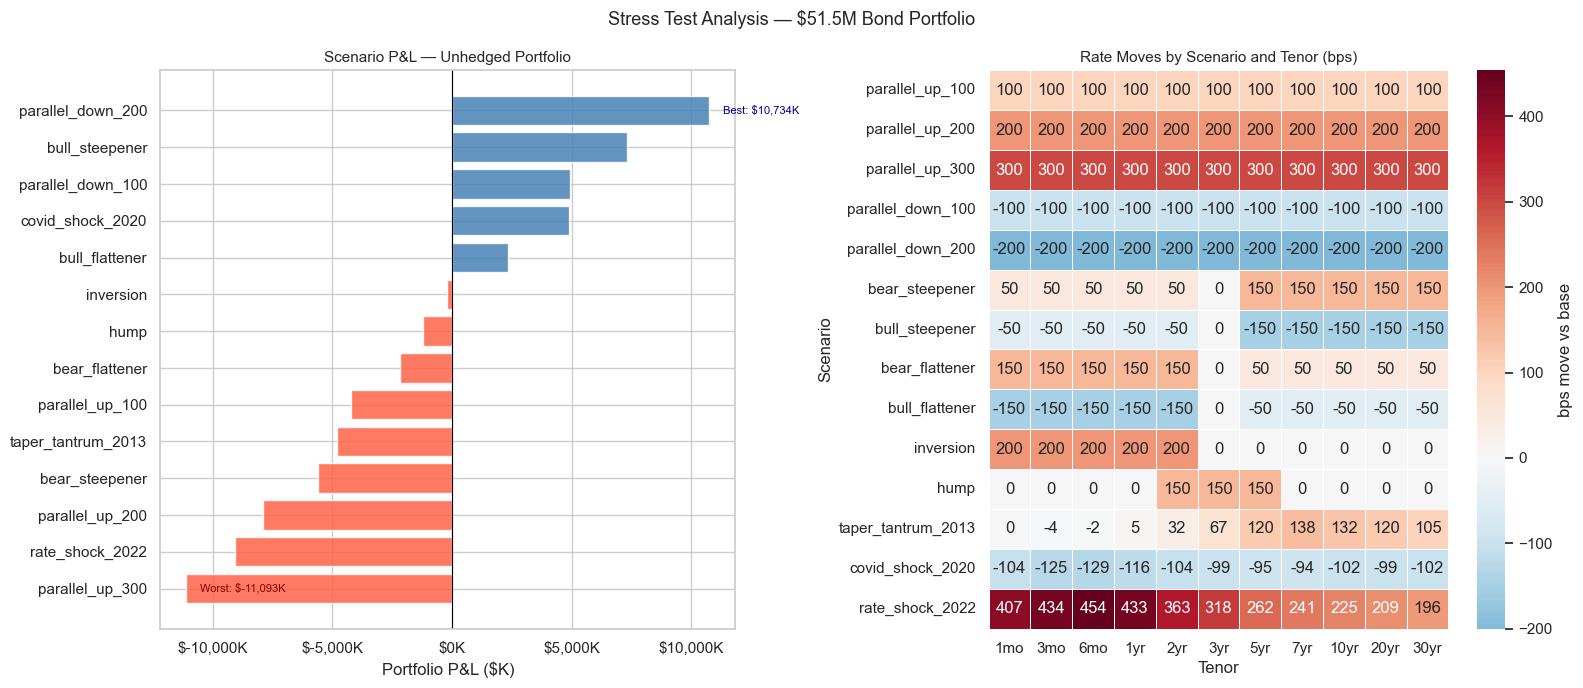


STRESS TEST SUMMARY
  Worst scenario : parallel_up_300
  Worst P&L      : $-11,092.9K  (-21.52% of portfolio)

  Best scenario  : parallel_down_200
  Best P&L       : $10,734.1K  (20.82% of portfolio)

  Scenarios with loss > $5M  : 9
  Scenarios with loss > $10M : 9

SCENARIO P&L DETAIL ($K):
----------------------------------------
  parallel_up_300           -$11092.9K  [LOSS]
  rate_shock_2022           -$ 9053.2K  [LOSS]
  parallel_up_200           -$ 7896.1K  [LOSS]
  bear_steepener            -$ 5584.8K  [LOSS]
  taper_tantrum_2013        -$ 4802.6K  [LOSS]
  parallel_up_100           -$ 4232.6K  [LOSS]
  bear_flattener            -$ 2191.9K  [LOSS]
  hump                      -$ 1233.9K  [LOSS]
  inversion                 -$  224.0K  [LOSS]
  bull_flattener            +$ 2351.7K  [GAIN]
  covid_shock_2020          +$ 4895.4K  [GAIN]
  parallel_down_100         +$ 4932.7K  [GAIN]
  bull_steepener            +$ 7320.2K  [GAIN]
  parallel_down_200         +$10734.1K  [GAIN]


In [27]:
# ── Stress Test Scenarios ─────────────────────────────────────
non_mc = [s for s in pnl_df.index if not s.startswith("mc_")]
pnl_total = pnl_df.loc[non_mc, "total"].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: Scenario P&L bar chart ─────────────────────────────
colors = ["tomato" if v < 0 else "steelblue" for v in pnl_total.values]
axes[0].barh(pnl_total.index, pnl_total.values / 1e3,
             color=colors, edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Portfolio P&L ($K)")
axes[0].set_title("Scenario P&L — Unhedged Portfolio", fontsize=11)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

# Annotate worst and best
worst_sc = pnl_total.idxmin()
best_sc  = pnl_total.idxmax()
axes[0].annotate(f"Worst: ${pnl_total.min()/1e3:,.0f}K",
                 xy=(pnl_total.min()/1e3, worst_sc),
                 xytext=(10, 0), textcoords="offset points",
                 fontsize=8, color="darkred", va="center")
axes[0].annotate(f"Best: ${pnl_total.max()/1e3:,.0f}K",
                 xy=(pnl_total.max()/1e3, best_sc),
                 xytext=(10, 0), textcoords="offset points",
                 fontsize=8, color="darkblue", va="center")

# ── Right: Scenario moves heatmap (non-MC) ───────────────────
heatmap_data = moves.loc[non_mc].astype(float)
sns.heatmap(heatmap_data, annot=True, fmt=".0f",
            cmap="RdBu_r", center=0,
            ax=axes[1], linewidths=0.4,
            cbar_kws={"label": "bps move vs base"})
axes[1].set_title("Rate Moves by Scenario and Tenor (bps)", fontsize=11)
axes[1].set_xlabel("Tenor")
axes[1].set_ylabel("Scenario")

plt.suptitle("Stress Test Analysis — $51.5M Bond Portfolio", fontsize=13)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────
print("\nSTRESS TEST SUMMARY")
print("=" * 50)
print(f"  Worst scenario : {worst_sc}")
print(f"  Worst P&L      : ${pnl_total.min()/1e3:,.1f}K  "
      f"({pnl_total.min()/port_price*100:.2f}% of portfolio)")
print(f"\n  Best scenario  : {best_sc}")
print(f"  Best P&L       : ${pnl_total.max()/1e3:,.1f}K  "
      f"({pnl_total.max()/port_price*100:.2f}% of portfolio)")
print(f"\n  Scenarios with loss > $5M  : "
      f"{(pnl_total < -5000).sum()}")
print(f"  Scenarios with loss > $10M : "
      f"{(pnl_total < -10000).sum()}")

print(f"\nSCENARIO P&L DETAIL ($K):")
print("-" * 40)
for sc, val in pnl_total.items():
    bar   = "█" * int(abs(val) / 500)
    sign  = "-" if val < 0 else "+"
    color_label = "LOSS" if val < 0 else "GAIN"
    print(f"  {sc:<25} {sign}${abs(val)/1e3:>7.1f}K  [{color_label}]")

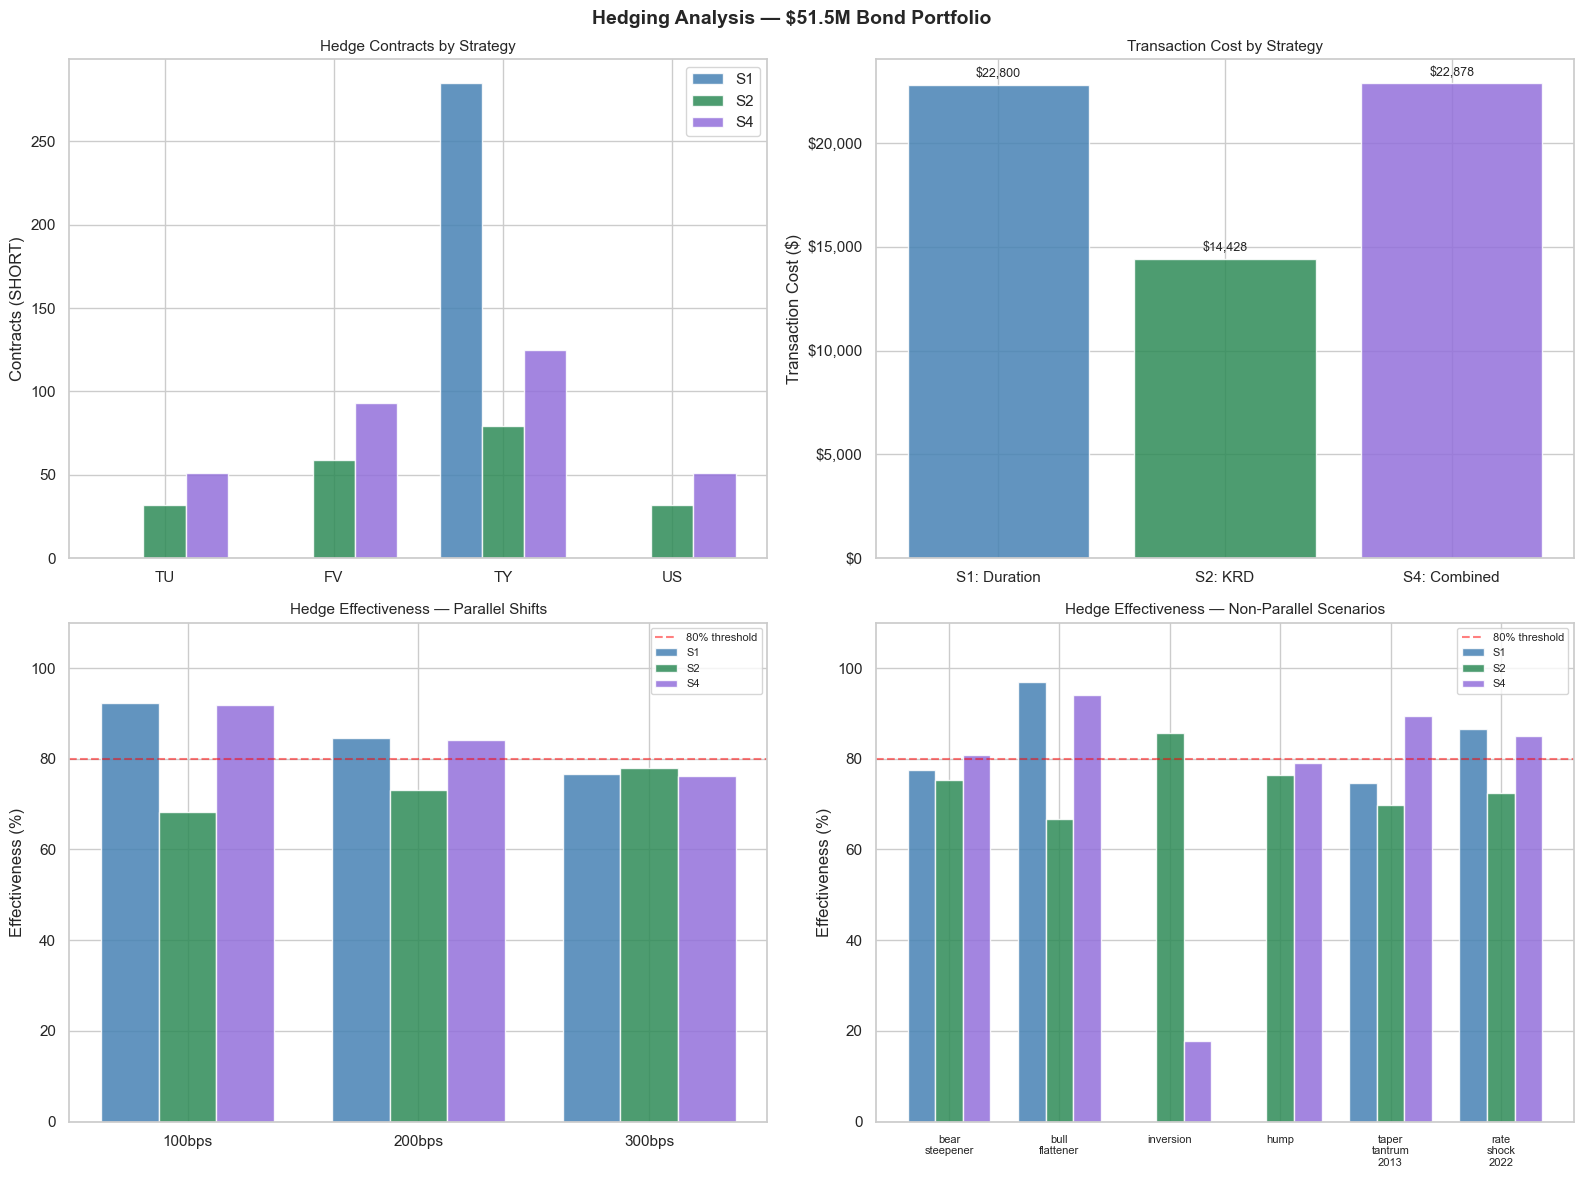


HEDGE EFFECTIVENESS SUMMARY

Strategy       Parallel Avg    Inversion     Hump       Cost
------------------------------------------------------------
S1: Duration          84.5%         0.0%     0.0%    22,800
S2: KRD               73.1%        85.7%    76.5%    14,428
S4: Combined          84.1%        17.8%    79.1%    22,878

Key insight: S1 is blind to inversion and hump (0% effective).
S4 resolves the S1 vs S2 tradeoff — strong across all scenario types.


In [28]:
# ── Hedging Analysis ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Top Left: Hedge Ratios (contracts per strategy) ──────────
strategies  = ["S1", "S2", "S4"]
tickers     = ["TU", "FV", "TY", "US"]
x           = np.arange(len(tickers))
width       = 0.25
colors_s    = ["steelblue", "seagreen", "mediumpurple"]

for i, (s, color) in enumerate(zip(strategies, colors_s)):
    axes[0,0].bar(x + i*width, hedge_ratios_df[s],
                  width, label=s, color=color,
                  alpha=0.85, edgecolor="white")

axes[0,0].set_xticks(x + width)
axes[0,0].set_xticklabels(tickers)
axes[0,0].set_ylabel("Contracts (SHORT)")
axes[0,0].set_title("Hedge Contracts by Strategy", fontsize=11)
axes[0,0].legend()

# ── Top Right: Transaction Costs ─────────────────────────────
tc_values = [tc_s1, tc_s2, tc_s4]
tc_labels = ["S1: Duration", "S2: KRD", "S4: Combined"]
bar_colors = ["steelblue", "seagreen", "mediumpurple"]
bars = axes[0,1].bar(tc_labels, tc_values,
                     color=bar_colors, alpha=0.85, edgecolor="white")
axes[0,1].bar_label(bars, fmt="${:,.0f}", padding=3, fontsize=9)
axes[0,1].set_ylabel("Transaction Cost ($)")
axes[0,1].set_title("Transaction Cost by Strategy", fontsize=11)
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── Bottom Left: Effectiveness on Parallel Shifts ────────────
parallel_eff = eff_df.loc[
    ["parallel_up_100","parallel_up_200","parallel_up_300"],
    ["s1_eff_%","s2_eff_%","s4_eff_%"]
]
parallel_eff.columns = ["S1","S2","S4"]
parallel_eff.index   = ["100bps","200bps","300bps"]
x2    = np.arange(3)
width2 = 0.25

for i, (s, color) in enumerate(zip(["S1","S2","S4"], colors_s)):
    axes[1,0].bar(x2 + i*width2, parallel_eff[s],
                  width2, label=s, color=color,
                  alpha=0.85, edgecolor="white")

axes[1,0].set_xticks(x2 + width2)
axes[1,0].set_xticklabels(["100bps","200bps","300bps"])
axes[1,0].set_ylabel("Effectiveness (%)")
axes[1,0].set_ylim(0, 110)
axes[1,0].axhline(80, color="red", linestyle="--",
                  alpha=0.5, label="80% threshold")
axes[1,0].set_title("Hedge Effectiveness — Parallel Shifts", fontsize=11)
axes[1,0].legend(fontsize=8)

# ── Bottom Right: Effectiveness on Non-Parallel Scenarios ────
key_scenarios = ["bear_steepener", "bull_flattener",
                 "inversion", "hump",
                 "taper_tantrum_2013", "rate_shock_2022"]
key_scenarios = [s for s in key_scenarios if s in eff_df.index]

nonpar_eff = eff_df.loc[
    key_scenarios,
    ["s1_eff_%","s2_eff_%","s4_eff_%"]
].copy()
nonpar_eff.columns = ["S1","S2","S4"]
nonpar_eff.index   = [s.replace("_","\n") for s in key_scenarios]

x3     = np.arange(len(key_scenarios))
width3 = 0.25

for i, (s, color) in enumerate(zip(["S1","S2","S4"], colors_s)):
    axes[1,1].bar(x3 + i*width3, nonpar_eff[s],
                  width3, label=s, color=color,
                  alpha=0.85, edgecolor="white")

axes[1,1].set_xticks(x3 + width3)
axes[1,1].set_xticklabels(nonpar_eff.index, fontsize=8)
axes[1,1].set_ylabel("Effectiveness (%)")
axes[1,1].set_ylim(0, 110)
axes[1,1].axhline(80, color="red", linestyle="--",
                  alpha=0.5, label="80% threshold")
axes[1,1].set_title("Hedge Effectiveness — Non-Parallel Scenarios", fontsize=11)
axes[1,1].legend(fontsize=8)

plt.suptitle("Hedging Analysis — $51.5M Bond Portfolio",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Effectiveness summary ─────────────────────────────────────
print("\nHEDGE EFFECTIVENESS SUMMARY")
print("=" * 60)
print(f"\n{'Strategy':<12} {'Parallel Avg':>14} {'Inversion':>12} {'Hump':>8} {'Cost':>10}")
print("-" * 60)

for s, label, tc in [
    ("s1_eff_%", "S1: Duration",  tc_s1),
    ("s2_eff_%", "S2: KRD",       tc_s2),
    ("s4_eff_%", "S4: Combined",  tc_s4),
]:
    par_avg  = eff_df.loc[["parallel_up_100","parallel_up_200",
                            "parallel_up_300"], s].mean()
    inv_eff  = eff_df.loc["inversion", s]
    hump_eff = eff_df.loc["hump", s]
    print(f"{label:<12} {par_avg:>13.1f}% {inv_eff:>11.1f}% "
          f"{hump_eff:>7.1f}% {tc:>9,.0f}")

print(f"\nKey insight: S1 is blind to inversion and hump (0% effective).")
print(f"S4 resolves the S1 vs S2 tradeoff — strong across all scenario types.")

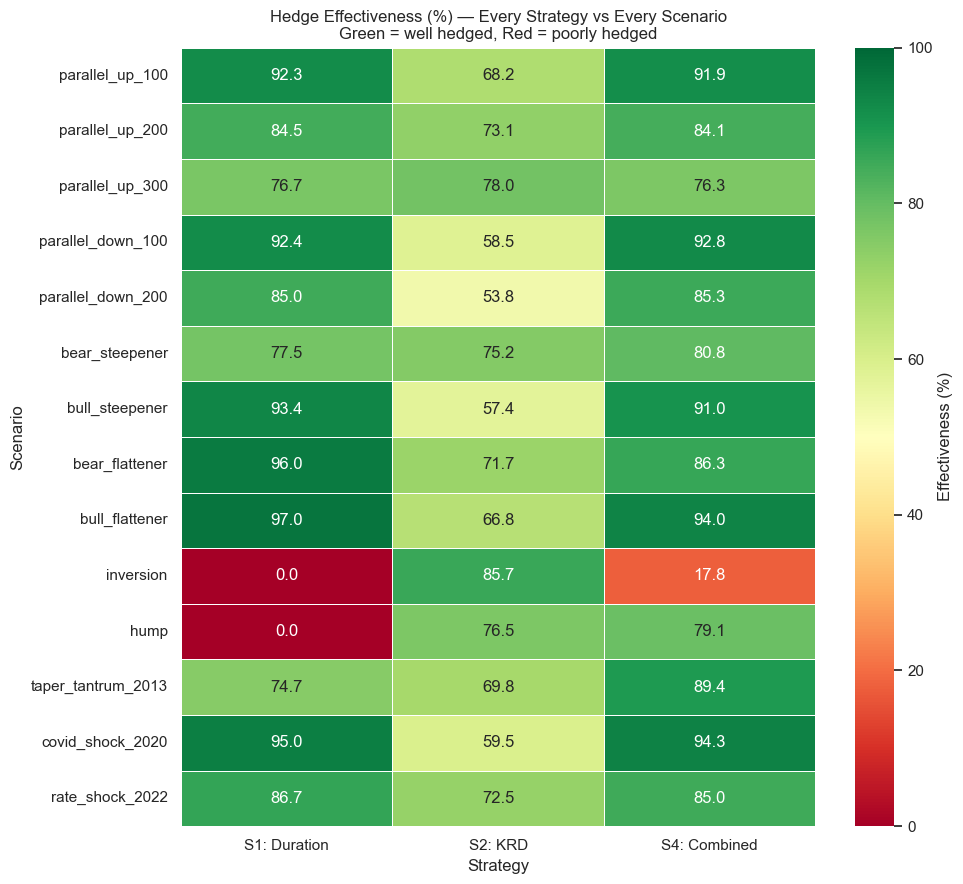

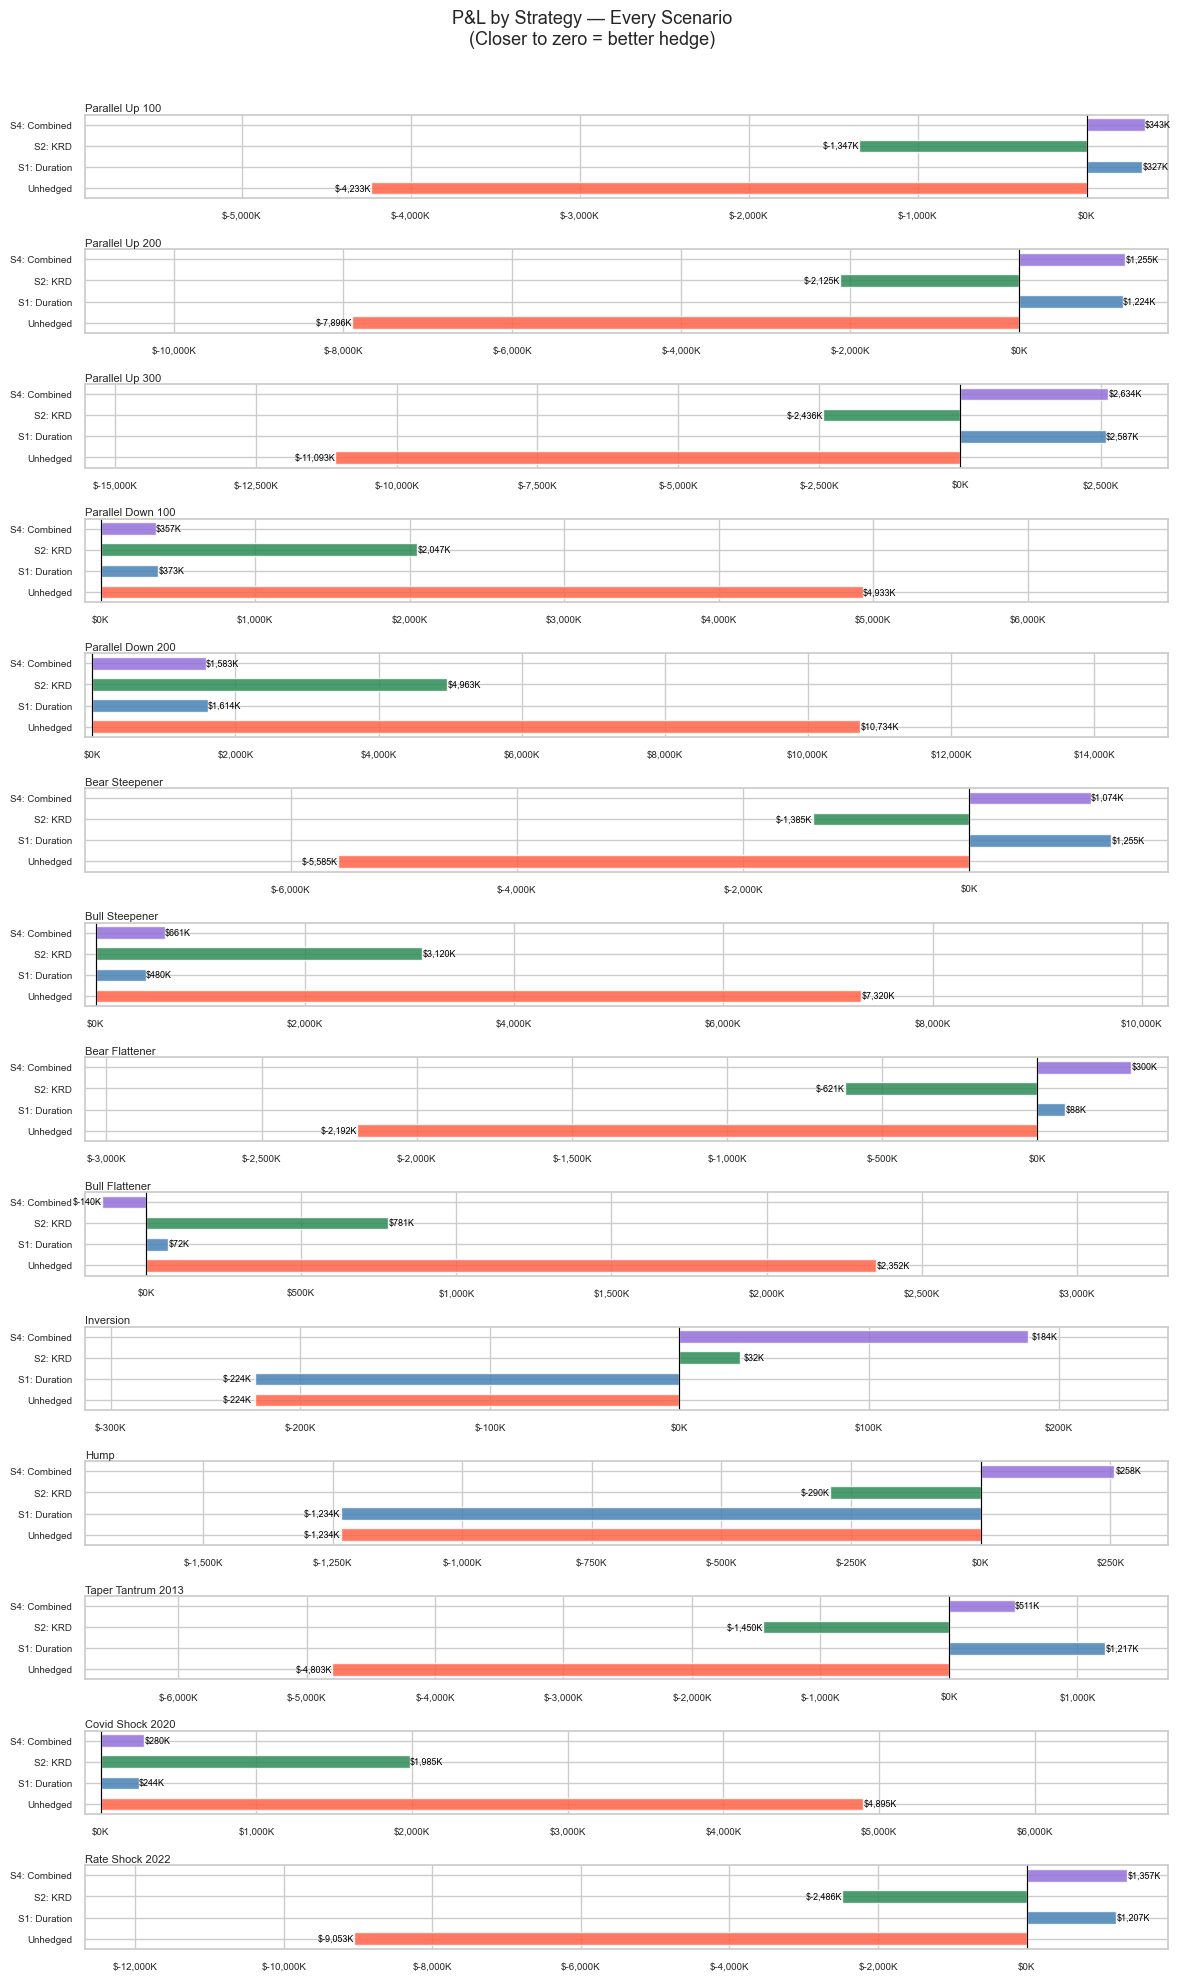

FULL STRATEGY vs SCENARIO BREAKDOWN
Scenario                    Unhedged    S1 ($K)  S1 Eff%    S2 ($K)  S2 Eff%    S4 ($K)  S4 Eff%
-----------------------------------------------------------------------------------------------
parallel_up_100             -4,232.6      327.4    92.3%   -1,347.1    68.2%      342.9    91.9%
parallel_up_200             -7,896.1    1,223.9    84.5%   -2,125.1    73.1%    1,254.9    84.1%
parallel_up_300            -11,092.9    2,587.1    76.7%   -2,436.4    78.0%    2,633.6    76.3%
parallel_down_100            4,932.7      372.7    92.4%    2,047.2    58.5%      357.2    92.8%
parallel_down_200           10,734.1    1,614.1    85.0%    4,963.1    53.8%    1,583.1    85.3%
bear_steepener              -5,584.8    1,255.2    77.5%   -1,384.6    75.2%    1,074.4    80.8%
bull_steepener               7,320.2      480.2    93.4%    3,120.0    57.4%      661.0    91.0%
bear_flattener              -2,191.9       88.1    96.0%     -621.2    71.7%      299.8    8

In [29]:
# ── Strategy vs Scenario Deep Dive ───────────────────────────

# ── Part 1: Full Effectiveness Heatmap ───────────────────────
eff_matrix = eff_df[["s1_eff_%","s2_eff_%","s4_eff_%"]].copy()
eff_matrix.columns = ["S1: Duration", "S2: KRD", "S4: Combined"]

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(eff_matrix.astype(float),
            annot=True, fmt=".1f",
            cmap="RdYlGn", center=50,
            vmin=0, vmax=100,
            ax=ax, linewidths=0.5,
            cbar_kws={"label": "Effectiveness (%)"})
ax.set_title("Hedge Effectiveness (%) — Every Strategy vs Every Scenario\n"
             "Green = well hedged, Red = poorly hedged", fontsize=12)
ax.set_xlabel("Strategy")
ax.set_ylabel("Scenario")
plt.tight_layout()
plt.show()


# ── Part 2: P&L Before and After Hedge per Scenario ──────────
fig, axes = plt.subplots(len(non_mc_scenarios), 1,
                         figsize=(12, len(non_mc_scenarios) * 1.4),
                         sharex=False)

strategies_plot = {
    "Unhedged":     ("unhedged",  "tomato"),
    "S1: Duration": ("s1_hedged", "steelblue"),
    "S2: KRD":      ("s2_hedged", "seagreen"),
    "S4: Combined": ("s4_hedged", "mediumpurple"),
}

for ax, sc in zip(axes, non_mc_scenarios):
    vals   = [hedged_df.loc[sc, col] / 1e3
              for col in ["unhedged","s1_hedged","s2_hedged","s4_hedged"]]
    labels = list(strategies_plot.keys())
    colors = [v[1] for v in strategies_plot.values()]
    bars   = ax.barh(labels, vals, color=colors, alpha=0.85,
                     edgecolor="white", height=0.6)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(sc.replace("_"," ").title(), fontsize=8,
                 loc="left", pad=2)
    ax.set_xlim(
        min(vals) * 1.4 if min(vals) < 0 else -100,
        max(vals) * 1.4 if max(vals) > 0 else 100
    )
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=7)

    # Annotate values
    for bar, val in zip(bars, vals):
        ax.text(val + (2 if val >= 0 else -2),
                bar.get_y() + bar.get_height()/2,
                f"${val:,.0f}K",
                va="center", ha="left" if val >= 0 else "right",
                fontsize=6.5, color="black")

plt.suptitle("P&L by Strategy — Every Scenario\n"
             "(Closer to zero = better hedge)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# ── Part 3: Quantification Table ─────────────────────────────
print("FULL STRATEGY vs SCENARIO BREAKDOWN")
print("=" * 95)
print(f"{'Scenario':<25} {'Unhedged':>10} {'S1 ($K)':>10} {'S1 Eff%':>8} "
      f"{'S2 ($K)':>10} {'S2 Eff%':>8} {'S4 ($K)':>10} {'S4 Eff%':>8}")
print("-" * 95)

for sc in non_mc_scenarios:
    row = hedged_df.loc[sc]
    e   = eff_df.loc[sc]
    print(f"{sc:<25} "
          f"{row['unhedged']/1e3:>10,.1f} "
          f"{row['s1_hedged']/1e3:>10,.1f} {e['s1_eff_%']:>7.1f}% "
          f"{row['s2_hedged']/1e3:>10,.1f} {e['s2_eff_%']:>7.1f}% "
          f"{row['s4_hedged']/1e3:>10,.1f} {e['s4_eff_%']:>7.1f}%")

print("-" * 95)

# Averages at the bottom
print(f"\n{'Average (all scenarios)':<25} "
      f"{'':>10} "
      f"{'':>10} {eff_df['s1_eff_%'].mean():>7.1f}% "
      f"{'':>10} {eff_df['s2_eff_%'].mean():>7.1f}% "
      f"{'':>10} {eff_df['s4_eff_%'].mean():>7.1f}%")

print(f"{'Average (parallel only)':<25} "
      f"{'':>10} "
      f"{'':>10} {eff_df.loc[['parallel_up_100','parallel_up_200','parallel_up_300'],'s1_eff_%'].mean():>7.1f}% "
      f"{'':>10} {eff_df.loc[['parallel_up_100','parallel_up_200','parallel_up_300'],'s2_eff_%'].mean():>7.1f}% "
      f"{'':>10} {eff_df.loc[['parallel_up_100','parallel_up_200','parallel_up_300'],'s4_eff_%'].mean():>7.1f}%")

print(f"{'Average (non-parallel)':<25} "
      f"{'':>10} "
      f"{'':>10} {eff_df.loc[non_parallel,'s1_eff_%'].mean():>7.1f}% "
      f"{'':>10} {eff_df.loc[non_parallel,'s2_eff_%'].mean():>7.1f}% "
      f"{'':>10} {eff_df.loc[non_parallel,'s4_eff_%'].mean():>7.1f}%")

print(f"\n{'Best strategy per scenario:'}")
print("-" * 45)
for sc in non_mc_scenarios:
    e = eff_df.loc[sc, ["s1_eff_%","s2_eff_%","s4_eff_%"]]
    best = {"s1_eff_%": "S1", "s2_eff_%": "S2", "s4_eff_%": "S4"}[e.idxmax()]
    print(f"  {sc:<25} → {best}  ({e.max():.1f}%)")

In [30]:
# ── Hedging Cost Analysis ─────────────────────────────────────
print("HEDGING COST — STRATEGY 4 (Combined Hedge)")
print("=" * 55)

# Contract breakdown
print("\nContracts to SHORT:")
total_contracts = 0
for tkr in ["TU", "FV", "TY", "US"]:
    n        = n_s4[tkr]
    cost     = n * TC_PER_CONTRACT[tkr]
    total_contracts += n
    print(f"  {tkr} ({futures.loc[tkr,'name']:12s}): "
          f"{n:>4d} contracts  ×  ${TC_PER_CONTRACT[tkr]:.0f}/contract  "
          f"=  ${cost:,.0f}")

print(f"\n  Total contracts    : {total_contracts}")
print(f"  Total hedge cost   : ${tc_s4:,.0f}")
print(f"  Portfolio value    : ${port_price/1e6:.2f}M")
print(f"  Cost as % of AUM   : {tc_s4/port_price*100:.4f}%")
print(f"  Cost per $1M hedged: ${tc_s4/(port_price/1e6):,.0f}")

# Put it in perspective
print(f"\nCOST vs PROTECTION:")
print(f"  Worst unhedged loss (rate_shock_2022): "
      f"${pnl_df.loc['rate_shock_2022','total']/1e3:,.1f}K")
print(f"  Hedged loss under S4                : "
      f"${hedged_df.loc['rate_shock_2022','s4_hedged']/1e3:,.1f}K")
print(f"  Loss avoided                        : "
      f"${(pnl_df.loc['rate_shock_2022','total'] - hedged_df.loc['rate_shock_2022','s4_hedged'])/1e3:,.1f}K")
print(f"  Hedge cost                          : ${tc_s4:,.0f}")
print(f"  Return on hedge cost                : "
      f"{abs(pnl_df.loc['rate_shock_2022','total'] - hedged_df.loc['rate_shock_2022','s4_hedged'])/tc_s4:.0f}x")

HEDGING COST — STRATEGY 4 (Combined Hedge)

Contracts to SHORT:
  TU (2yr Note    ):   51 contracts  ×  $20/contract  =  $1,020
  FV (5yr Note    ):   93 contracts  ×  $42/contract  =  $3,952
  TY (10yr Note   ):  125 contracts  ×  $80/contract  =  $10,000
  US (30yr Bond   ):   51 contracts  ×  $155/contract  =  $7,905

  Total contracts    : 320
  Total hedge cost   : $22,878
  Portfolio value    : $51.55M
  Cost as % of AUM   : 0.0444%
  Cost per $1M hedged: $444

COST vs PROTECTION:
  Worst unhedged loss (rate_shock_2022): $-9,053.2K
  Hedged loss under S4                : $1,357.2K
  Loss avoided                        : $-10,410.4K
  Hedge cost                          : $22,878
  Return on hedge cost                : 455x
